# Importar librerías

In [44]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


# Librerías de simulación y análisis

In [45]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
)
from src.sky_apex_plotter import plot_cluster_motion_geometry

In [46]:
# # antapex solar
# l = 312.20
# b = -23.70

# coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
# coord_icrs = coord_gal.icrs

# coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

In [47]:
# # apex solar
# l = 47.8
# b = 23.7

# coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
# coord_icrs = coord_gal.icrs

# coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

In [48]:
from astropy.coordinates import SkyCoord
from astropy import units as u

# # Punto 1
# l1 = 312.20
# b1 = -23.70

# # Punto 2
# l2 = 47.8
# b2 = 23.7

# coord1 = SkyCoord(l=l1*u.deg, b=b1*u.deg, frame="galactic")
# coord2 = SkyCoord(l=l2*u.deg, b=b2*u.deg, frame="galactic")

# sep = coord1.separation(coord2)

# print(sep)
# print(sep.deg)

# Cargue de datos

In [49]:
cluster_real = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")

In [50]:
cluster_real = correct_gaia_proper_motions(
    cluster_real,
    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",
    pmra_col="pmra",
    pmdec_col="pmdec",
    correct_solar_reflex=True
)

In [51]:
import astropy.units as u
from astropy.coordinates import SkyCoord

coord_gal = SkyCoord(l=177.565674*u.deg, b=-25.7529*u.deg, frame='galactic')
coord_icrs = coord_gal.icrs

# Configuración de simulaciones

## Configuración de sintéticas

In [52]:
# ============================================================
# Modelos de error reutilizables
# ============================================================

PMRA_LOG10_TRIANGULAR_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,
)

PMDEC_LOG10_TRIANGULAR_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,
)

GAIA_LIKE_PM_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,

    # Relación empírica:
    # pmdec_error ≈ 0.7 * pmra_error
    pm_error_slope=1,

    # Correlación entre perturbaciones de pmra y pmdec.
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    pm_error_slope_logscatter=0.08,
)


# ============================================================
# Caso 1: cúmulo ideal con ápex Hyades
# ============================================================

config_hyades = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,
)


# ============================================================
# Caso 2: cúmulo ideal con ápex solar
# ============================================================

config_hyades_solar = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=227.79628626384542,
    apex_dec_deg=-23.69031810716205,

    speed_kms=25.0,
    seed=42,
)


# ============================================================
# Caso 3: solo error en paralaje
# ============================================================

config_hyades_error_parallax = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Solo error observacional en paralaje
    parallax_error_mas=0.03,
)


# ============================================================
# Caso 4: solo error en pmra
# pmra_error viene de:
# log10(pmra_error) ~ Triangular(-3, -1.7, 0)
# ============================================================

config_hyades_error_pmra = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    **PMRA_LOG10_TRIANGULAR_ERROR,
)


# ============================================================
# Caso 5: solo error en pmdec
# Este lo mantengo constante porque el modelo triangular fue
# definido explícitamente para pmra_error.
# ============================================================

config_hyades_error_pmdec = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    **PMDEC_LOG10_TRIANGULAR_ERROR,
)


# ============================================================
# Caso 6: errores en pmra y pmdec Gaia-like
#
# pmra_error:
# log10(pmra_error) ~ Triangular(-3, -1.7, 0)
#
# pmdec_error:
# pmdec_error ≈ 0.7 * pmra_error
#
# perturbaciones:
# corr(dpmra, dpmdec) = 0.2
# ============================================================

config_hyades_error_pm = ClusterSimulationConfig(
    n_members=455,
    center_ra_deg=67.0,
    center_dec_deg=17.0,
    distance_pc=85.0,
    radius_pc=5.0,
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,
    speed_kms=25.0,
    seed=42,
    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,
)


# ============================================================
# Caso 7: paralaje + movimientos propios Gaia-like
# ============================================================

config_hyades_error_all = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.04,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,
)

# ============================================================
# Caso 8: dispersión física/intrínseca en velocidad
#
# Importante:
# speed_sigma_kms no es un error observacional Gaia.
# Es una dispersión real de velocidades dentro del cúmulo.
# Para un cúmulo abierto realista, 5 km/s es bastante alto.
# Puedes usarlo como prueba extrema, pero para algo más físico
# usaría valores como 0.3, 0.5 o 1.0 km/s.
# ============================================================

config_hyades_error_dispersion = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Dispersión física, no error observacional
    speed_sigma_kms=5.0,
)


# ============================================================
# Caso 9: paralaje + movimientos propios Gaia-like
#         + dispersión física/intrínseca en velocidad
# ============================================================

config_hyades_error_alld = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.03,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,

    # Dispersión física, no error observacional
    speed_sigma_kms=5.0,
)

## generación de simulaciones sintéticas

In [53]:
# ejecución de simulación del cúmulo sintético de las hyades
simulator_hyades = OpenClusterSimulator(config_hyades)
simulator_hyades_solar = OpenClusterSimulator(config_hyades_solar)
simulator_hyades_error_parallax = OpenClusterSimulator(config_hyades_error_parallax)
simulator_hyades_error_pmra = OpenClusterSimulator(config_hyades_error_pmra)
simulator_hyades_error_pmdec = OpenClusterSimulator(config_hyades_error_pmdec)
simulator_hyades_error_pm = OpenClusterSimulator(config_hyades_error_pm)
simulator_hyades_error_all = OpenClusterSimulator(config_hyades_error_all)
simulator_hyades_error_dispersion = OpenClusterSimulator(config_hyades_error_dispersion)
simulator_hyades_error_alld = OpenClusterSimulator(config_hyades_error_alld)

hyades_sintetico = simulator_hyades.simulate()
hyades_sintetico["cluster_id"] ="0_8"
hyades_sintetico["grupo"] = "1"

hyades_sintetico_solar = simulator_hyades_solar.simulate()
hyades_sintetico_solar["cluster_id"] ="0_8"
hyades_sintetico_solar["grupo"] = "1"

hyades_sintetico_error_parallax = simulator_hyades_error_parallax.simulate()
hyades_sintetico_error_parallax["cluster_id"] ="0_8"
hyades_sintetico_error_parallax["grupo"] = "1"

hyades_sintetico_error_pmra = simulator_hyades_error_pmra.simulate()
hyades_sintetico_error_pmra["cluster_id"] ="0_8"
hyades_sintetico_error_pmra["grupo"] = "1"

hyades_sintetico_error_pmdec = simulator_hyades_error_pmdec.simulate()
hyades_sintetico_error_pmdec["cluster_id"] ="0_8"
hyades_sintetico_error_pmdec["grupo"] = "1"

hyades_sintetico_error_pm = simulator_hyades_error_pm.simulate()
hyades_sintetico_error_pm["cluster_id"] ="0_8"
hyades_sintetico_error_pm["grupo"] = "1"

hyades_sintetico_error_all = simulator_hyades_error_all.simulate()
hyades_sintetico_error_all["cluster_id"] ="0_8"
hyades_sintetico_error_all["grupo"] = "1"

hyades_sintetico_error_dispersion = simulator_hyades_error_dispersion.simulate()
hyades_sintetico_error_dispersion["cluster_id"] ="0_8"
hyades_sintetico_error_dispersion["grupo"] = "1"

hyades_sintetico_error_alld = simulator_hyades_error_alld.simulate()
hyades_sintetico_error_alld["cluster_id"] ="0_8"
hyades_sintetico_error_alld["grupo"] = "1"

## Generación de simulaciones semi-sintéticas

In [11]:
apex_hyades_ra = 97.89
apex_hyades_dec = 6.61
apex_solar_ra = 227.79628626384542
apex_solar_dec = -23.69031810716205

# Simulacion con valores reportados de velocidad
simulado_uvw = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


# Simulacion con el valor de apex del cumulo
simulado_apex = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_hyades_ra,
    apex_dec_deg=apex_hyades_dec,
    speed_kms=np.sqrt(41.92**2 + 19.35**2 + 1.11**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


simulado_uvw_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)


# Simulacion con errores Gaia-like en movimientos propios
simulado_apex_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=apex_solar_ra,
    apex_dec_deg=apex_solar_dec,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    # Aquí sí activas errores observacionales en movimientos propios
    apply_pmra_error=True,
    apply_pmdec_error=True,
    apply_parallax_error=False,

    # Error en pmra:
    # log10(pmra_error) ~ Triangular(-3, -1.7, 0)
    pmra_log_error_range=(-3.0, 0.0),
    pmra_log_error_center=-1.7,

    # Error en pmdec:
    # pmdec_error ≈ 0.7 * pmra_error
    pmdec_error_model="scaled_pmra",
    pm_error_slope=0.7,

    # Correlación entre las perturbaciones aleatorias
    # de pmra y pmdec
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    # Puedes poner 0.0 si quieres una línea exacta.
    pm_error_slope_logscatter=0.08,

    seed=42,
)

In [12]:
simulado_uvw[["apex_ra_deg","apex_dec_deg"]].describe()

,apex_ra_deg,apex_dec_deg
count,4.550000e+02,4.550000e+02
mean,2.277963e+02,-2.369032e+01
std,2.361598e-12,2.133975e-13
min,2.277963e+02,-2.369032e+01
25%,2.277963e+02,-2.369032e+01
50%,2.277963e+02,-2.369032e+01
75%,2.277963e+02,-2.369032e+01
max,2.277963e+02,-2.369032e+01


## generación de análisis sintéticos

In [13]:
# ejecucion de cálculo de ápex para cúmulo sintético
result_hyades_sintetico = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_solar = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_parallax = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_parallax,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmra = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmra,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmdec = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmdec,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec
)

result_hyades_sintetico_error_pm = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pm,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_all = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_all,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_dispersion = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_dispersion,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec
)

# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_alld = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_alld,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)

## Generación de resultados semi-sintéticos

In [14]:
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad = run_cluster_analysis_from_dataframe(
    df = simulado_uvw,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex = run_cluster_analysis_from_dataframe(
    df = simulado_apex,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad_solar = run_cluster_analysis_from_dataframe(
    df = simulado_uvw_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex_solar = run_cluster_analysis_from_dataframe(
    df = simulado_apex_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic_corrected = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra_corr",
    pmdec_col = "pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
    true_apex_ra_deg=apex_hyades_ra,
    true_apex_dec_deg=apex_hyades_dec,
)
# ejecución sobre caso corregido hyades solar
cluster_real["peso"] =1/(1-cluster_real["probabilidad"])
result_hyades_classic_solar = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "d_pmra_corr",
    pmdec_col = "d_pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    # weight_fill_value =  1,
    weight_col = "peso",
    true_apex_ra_deg=apex_solar_ra,
    true_apex_dec_deg=apex_solar_dec,
)

# Análisis de resultados

## Agrupación de resultados

In [15]:
all_results = {
    "Hy_s": result_hyades_sintetico["summary"],
    "Hy_s err plx": result_hyades_sintetico_error_parallax["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err pmdec": result_hyades_sintetico_error_pmdec["summary"],
    "Hy_s err pm": result_hyades_sintetico_error_pm["summary"],
    "Hy_s err all": result_hyades_sintetico_error_all["summary"],
    "Hy_s err dispersion": result_hyades_sintetico_error_dispersion["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err alld": result_hyades_sintetico_error_alld["summary"],
    "Hy_ss vel": result_hyades_semisintetico_velocidad["summary"],
    "Hy_ss apex": result_hyades_semisintetico_apex["summary"], 
    "Hy_s solar": result_hyades_sintetico_solar["summary"],
    "Hy_ss vel solar": result_hyades_semisintetico_velocidad_solar["summary"],
    "Hy_ss apex solar": result_hyades_semisintetico_apex_solar["summary"],
    "Hy_ss classic": result_hyades_classic["summary"],
    "Hy_ss classic corrected": result_hyades_classic_corrected["summary"],
    "Hy_ss classic solar": result_hyades_classic_solar["summary"],
}

In [16]:
df_results = pd.DataFrame(
    [
        {
            "type": result_name,
            **result_dict,
        }
        for result_name, result_dict in all_results.items()
    ]
)

df_results[["type","n_stars","true_apex_ra_deg","true_apex_dec_deg","apex_initial_ra_deg","apex_initial_dec_deg",'theta_pole_initial_rms_deg', 'theta_pole_axis_initial_median_deg',
       'theta_pole_axis_initial_rms_deg']]

,type,n_stars,true_apex_ra_deg,true_apex_dec_deg,apex_initial_ra_deg,apex_initial_dec_deg,theta_pole_initial_rms_deg,theta_pole_axis_initial_median_deg,theta_pole_axis_initial_rms_deg
0,Hy_s,455,97.890000,6.610000,97.890002,6.620000,3.074419e-07,0.000000e+00,3.074419e-07
1,Hy_s err plx,455,97.890000,6.610000,97.890002,6.620000,3.074419e-07,0.000000e+00,3.074419e-07
2,Hy_s err pmra,455,97.890000,6.610000,97.846253,6.634782,4.266799e-02,9.352210e-03,4.266799e-02
3,Hy_s err pmdec,455,97.890000,6.610000,97.846253,6.634782,4.266799e-02,9.352210e-03,4.266799e-02
4,Hy_s err pm,455,97.890000,6.610000,97.685416,6.696755,2.093672e-01,2.919294e-02,2.093672e-01
5,Hy_s err all,455,97.890000,6.610000,97.692407,6.699655,1.774135e-01,3.161546e-02,1.774135e-01
6,Hy_s err dispersion,455,97.890000,6.610000,97.890002,6.620000,3.921685e-07,0.000000e+00,3.921685e-07
7,Hy_s err alld,455,97.890000,6.610000,97.677531,6.704062,1.976221e-01,3.365795e-02,1.976221e-01
8,Hy_ss vel,455,97.890000,6.610000,227.796286,-23.690318,3.534959e-07,0.000000e+00,3.534959e-07
9,Hy_ss apex,455,97.890000,6.610000,97.890005,6.610001,1.531467e-06,8.537736e-07,1.531467e-06


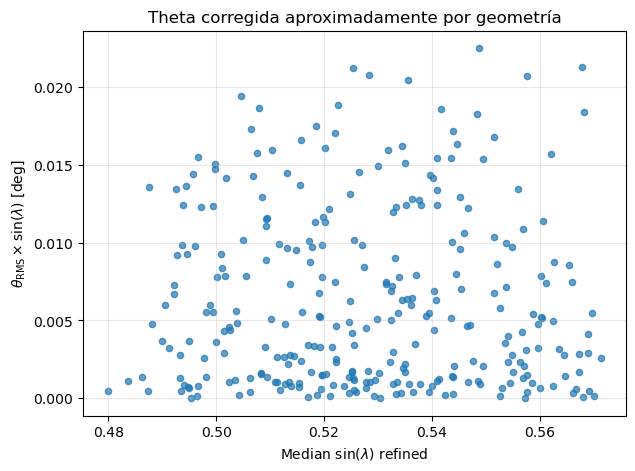

In [17]:
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"] = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]*result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_axis_refined_deg"]
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_cos_lambda"] = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["cos_lambda_refined"]*result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_axis_refined_deg"]
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["arc_sin_sin_theta_times_sin_lambda"] = np.arcsin(np.sin(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]*180/np.pi) * result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"])
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_theta_times_sin_lambda"] = np.sin(result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]*180/np.pi) * result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]
x = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_lambda_refined"]
y = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"]

mask = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7, 5))
plt.scatter(x[mask], y[mask], s=20, alpha=0.7)

plt.xlabel(r"Median $\sin(\lambda)$ refined")
plt.ylabel(r"$\theta_{\rm RMS} \times \sin(\lambda)$ [deg]")
plt.title("Theta corregida aproximadamente por geometría")
plt.grid(alpha=0.3)
plt.show()

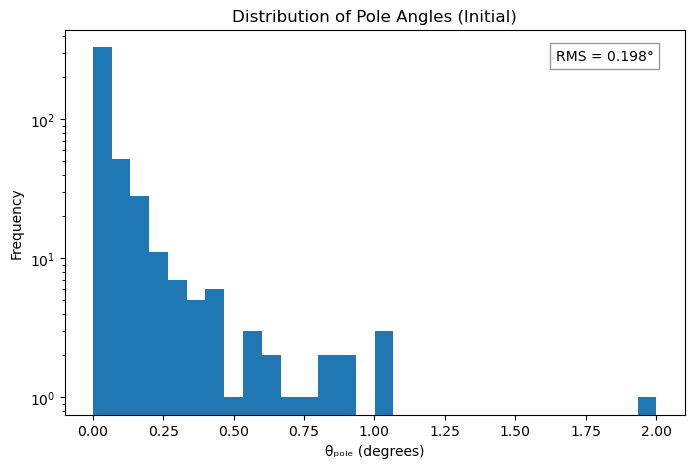

In [18]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_initial"]["theta_pole_initial_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Initial)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)
plt.yscale("log")
plt.show()

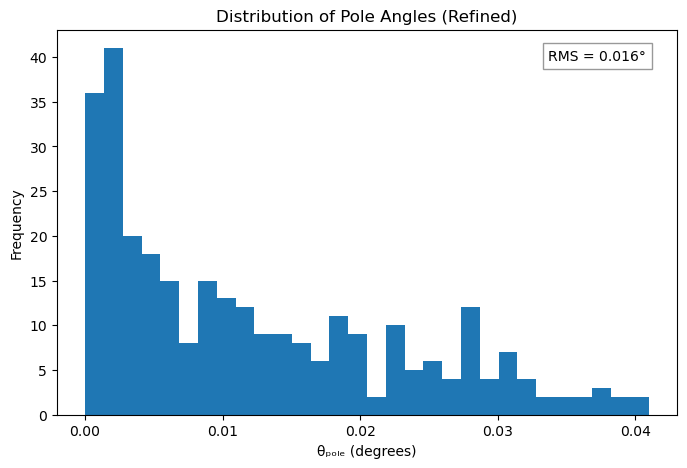

In [19]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_pole_refined_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\;'
<>:15: SyntaxWarning: invalid escape sequence '\;'
C:\Users\nicob\AppData\Local\Temp\ipykernel_32528\33341055.py:15: SyntaxWarning: invalid escape sequence '\;'
  plt.xlabel("θₚₒₗₑ $sin\;\lambda$ (degrees)")


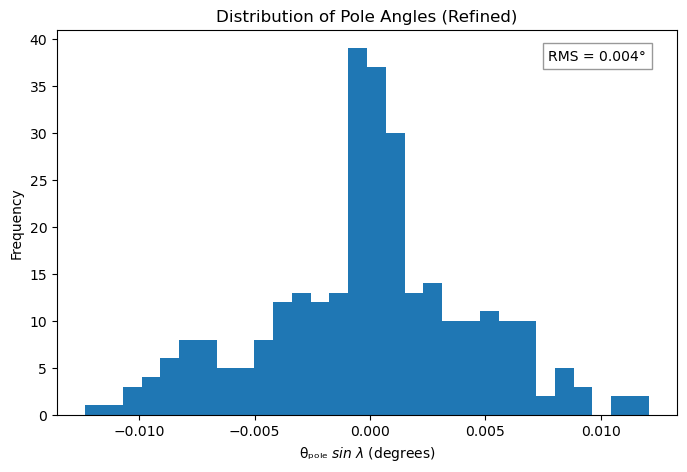

In [27]:
# Variable a graficar
# theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ $sin\;\lambda$ (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Pole Angles (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\;'
<>:15: SyntaxWarning: invalid escape sequence '\;'
C:\Users\nicob\AppData\Local\Temp\ipykernel_34628\3954969377.py:15: SyntaxWarning: invalid escape sequence '\;'
  plt.xlabel("θₚₒₗₑ $cos\;\lambda$ (degrees)")


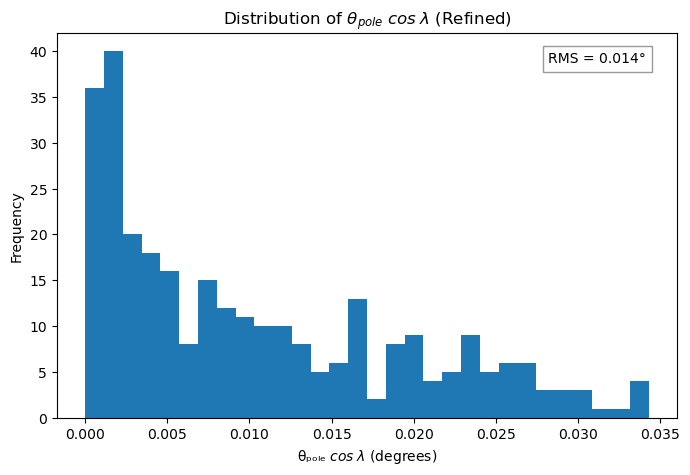

In [21]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["theta_times_cos_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel("θₚₒₗₑ $cos\;\lambda$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\theta_{pole}\;cos\;\lambda$ (Refined)")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

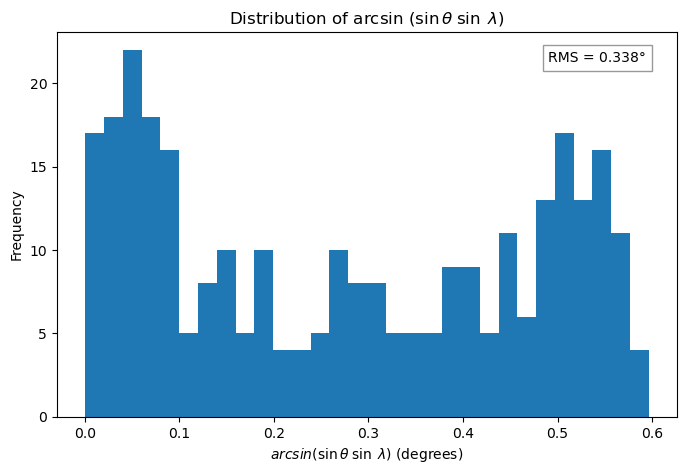

In [22]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["arc_sin_sin_theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$ arcsin (\sin\theta\; \sin\;\lambda)$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of arcsin $(\sin\theta\; \sin\;\lambda)$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

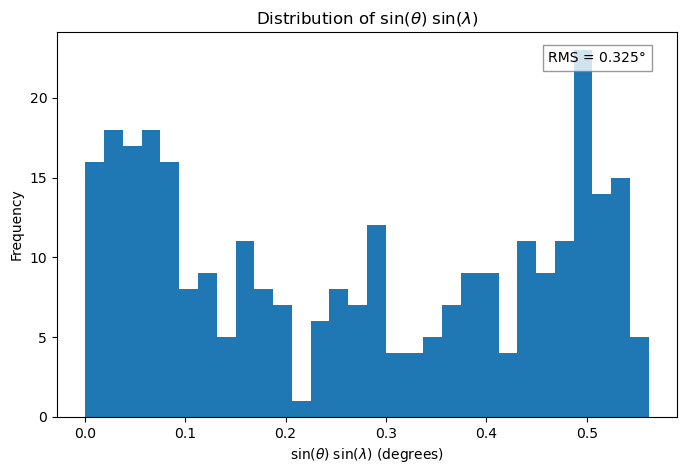

In [23]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["sin_theta_times_sin_lambda"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$\sin(\theta)\; \sin(\lambda)$ (degrees)")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\sin(\theta)\; \sin(\lambda)$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

In [34]:
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"].columns[:-30]

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'distance_pc_true', 'radial_velocity_kms_true', 'ra_true', 'dec_true',
       'parallax_true', 'pmra_true', 'pmdec_true', 'ra_error', 'dec_error',
       'parallax_error', 'pmra_error', 'pmdec_error', 'pmra_pmdec_corr',
       'cluster_id', 'grupo', 'distance_pc', 'probabilidad', 'x_initial',
       'y_initial', 'z_initial', 'x_final', 'y_final', 'z_final',
       'delta_ra_rad', 'delta_dec_rad', 'ra_final_rad', 'dec_final_rad',
       'pole_x', 'pole_y', 'pole_z', 'pole_norm', 'pole_x_unit', 'pole_y_unit',
       'pole_z_unit', 'lambda_rad', 'lambda_deg', 'sin_lambda', 'cos_lambda',
       'delta_ra_apex_rad', 'delta_ra_apex_deg', 'lambda_tangent_ra',
       'lambda_tangent_dec', 'perfect_pole_initial_x',
       'perfect_pole_initial_y', 'perfect_pole_initial_z',
       'perfect_pole_initial_norm', 'perfect_pole_initial_x_unit',
       'perfect_pole_initial_y_unit', 'perfect_pole_initial_z_unit',
       'theta_pole_i

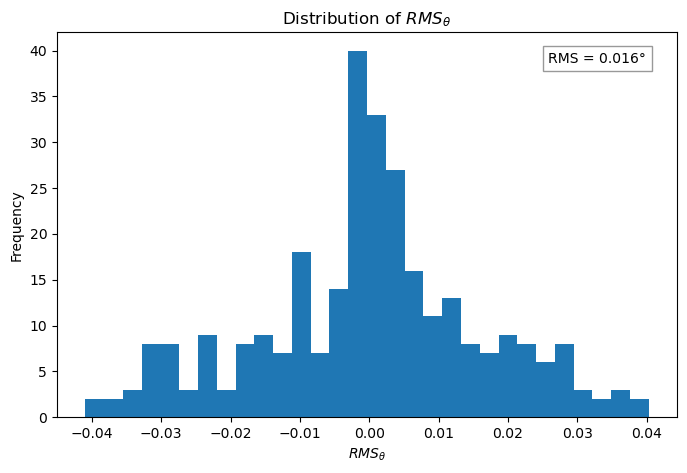

In [41]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_refined_deg"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$RMS_{\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $RMS_{\theta}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

In [26]:
result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]

,source_id,ra,dec,parallax,pmra,pmdec,distance_pc_true,radial_velocity_kms_true,ra_true,dec_true,parallax_true,pmra_true,pmdec_true,ra_error,dec_error,parallax_error,pmra_error,pmdec_error,pmra_pmdec_corr,cluster_id,grupo,distance_pc,probabilidad,x_initial,y_initial,z_initial,x_final,y_final,z_final,delta_ra_rad,delta_dec_rad,ra_final_rad,dec_final_rad,pole_x,pole_y,pole_z,pole_norm,pole_x_unit,pole_y_unit,pole_z_unit,lambda_rad,lambda_deg,sin_lambda,cos_lambda,delta_ra_apex_rad,delta_ra_apex_deg,lambda_tangent_ra,lambda_tangent_dec,perfect_pole_initial_x,perfect_pole_initial_y,perfect_pole_initial_z,perfect_pole_initial_norm,perfect_pole_initial_x_unit,perfect_pole_initial_y_unit,perfect_pole_initial_z_unit,theta_pole_initial_deg,theta_pole_axis_initial_deg,lambda_deg_initial,sin_lambda_initial,cos_lambda_initial,pole_apex_dot_initial,pole_apex_error_geom_signed_initial_deg,pole_apex_error_geom_abs_initial_deg,pole_apex_error_direction_ratio_initial,pole_apex_error_direction_signed_initial_deg,pole_apex_error_direction_abs_initial_deg,pm_total,vt_kms,theta_iter_final_is_inlier,theta_iter_final_is_outlier,perfect_pole_theta_iter_final_x,perfect_pole_theta_iter_final_y,perfect_pole_theta_iter_final_z,perfect_pole_theta_iter_final_norm,perfect_pole_theta_iter_final_x_unit,perfect_pole_theta_iter_final_y_unit,perfect_pole_theta_iter_final_z_unit,theta_pole_theta_iter_final_deg,theta_pole_axis_theta_iter_final_deg,perfect_pole_refined_x,perfect_pole_refined_y,perfect_pole_refined_z,perfect_pole_refined_norm,perfect_pole_refined_x_unit,perfect_pole_refined_y_unit,perfect_pole_refined_z_unit,theta_pole_refined_deg,theta_pole_axis_refined_deg,lambda_deg_refined,sin_lambda_refined,cos_lambda_refined,pole_apex_dot_refined,pole_apex_error_geom_signed_refined_deg,pole_apex_error_geom_abs_refined_deg,pole_apex_error_direction_ratio_refined,pole_apex_error_direction_signed_refined_deg,pole_apex_error_direction_abs_refined_deg,theta_times_sin_lambda,theta_times_cos_lambda,arc_sin_sin_theta_times_sin_lambda,sin_theta_times_sin_lambda
1,2,64.678271,15.851649,12.230032,39.804661,-8.491827,81.663776,23.534241,64.678271,15.851649,12.245331,39.804693,-8.494225,0.0,0.0,0.03,0.004256,0.002964,0.2,0_8,1,81.765935,1.0,0.411436,0.869546,0.273148,0.411436,0.869546,0.273147,2.006071e-07,-4.116954e-08,1.128849,0.276663,-5.975876e-08,-3.003884e-08,1.856399e-07,1.973211e-07,-0.302850,-0.152233,0.940801,0.589927,33.800345,0.556301,0.830981,0.579614,33.209448,0.977977,-0.208713,-0.167336,-0.084274,0.520335,0.553039,-0.302576,-0.152383,0.940865,0.018293,0.018293,33.575730,0.553039,0.833156,0.000177,0.010117,0.010117,0.000319,0.018293,0.018293,40.700395,15.775838,True,False,-0.168510,-0.084669,0.523360,0.556301,-0.302913,-0.152199,0.940787,0.004150,0.004150,-0.168510,-0.084669,0.523360,0.556301,-0.302913,-0.152199,0.940787,0.004150,0.004150,33.800345,0.556301,0.830981,-4.028887e-05,-0.002308,0.002308,-0.000072,-0.004150,0.004150,0.002308,0.003448,0.131396,0.131018
2,3,65.844205,17.245819,12.016909,39.527233,-10.477216,83.446833,24.866581,65.844205,17.245819,11.983678,39.522650,-10.462229,0.0,0.0,0.03,0.012512,0.010296,0.2,0_8,1,83.216078,1.0,0.390821,0.871414,0.296472,0.390821,0.871415,0.296472,2.006545e-07,-5.079498e-08,1.149198,0.300996,-6.959651e-08,-3.105280e-08,1.830179e-07,1.982511e-07,-0.351052,-0.156634,0.923162,0.576605,33.037024,0.545181,0.838318,0.559265,32.043514,0.966698,-0.255919,-0.190075,-0.084962,0.500292,0.541885,-0.350767,-0.156790,0.923244,0.019231,0.019231,32.812067,0.541885,0.840452,0.000182,0.010421,0.010421,0.000336,0.019231,0.019231,40.892227,16.131301,True,False,-0.191245,-0.085471,0.503331,0.545181,-0.350791,-0.156776,0.923237,0.017572,0.017572,-0.191245,-0.085471,0.503331,0.545181,-0.350791,-0.156776,0.923237,0.017572,0.017572,33.037024,0.545181,0.838318,1.672008e-04,0.009580,0.009580,0.000307,0.017572,0.017572,0.009580,0.014731,0.478836,0.460746
3,4,69.563317,18.287286,11.474694,31.183418,-10.926130,87.344825,23.756628,69.563317,18

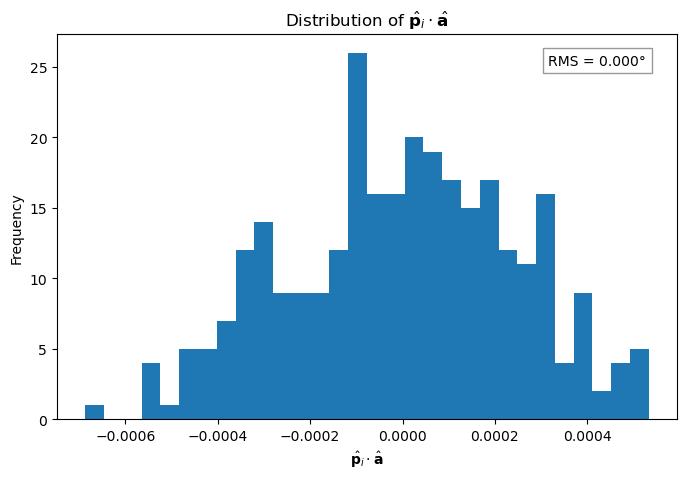

In [32]:
# Variable a graficar
theta = result_hyades_sintetico_error_alld["cluster_result"]["data_refined"]["pole_apex_dot_initial"]

# Quitar NaN si existen
theta = np.asarray(theta)
theta = theta[~np.isnan(theta)]

# Calcular RMS
rms_theta = np.sqrt(np.mean(theta**2))

# Graficar
plt.figure(figsize=(8, 5))
plt.hist(theta, bins=30)

plt.xlabel(r"$\hat{\mathbf{p}}_i\cdot\hat{\mathbf{a}}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\hat{\mathbf{p}}_i\cdot\hat{\mathbf{a}}$")

# Mostrar RMS en la gráfica
plt.text(
    0.95, 0.95,
    f"RMS = {rms_theta:.3f}°",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.show()

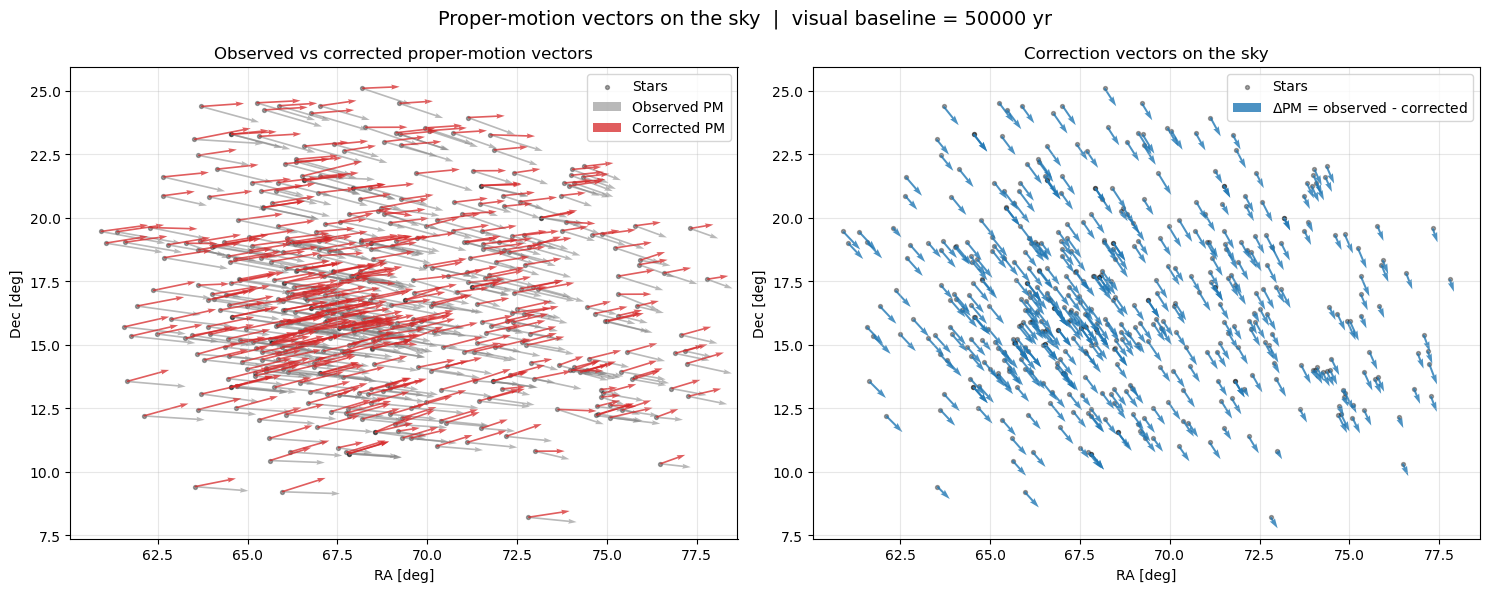

In [34]:
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra",
    pmdec_col="pmdec",
    pmra_corr_col="pmra_corr",
    pmdec_corr_col="pmdec_corr",
    years=50000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)

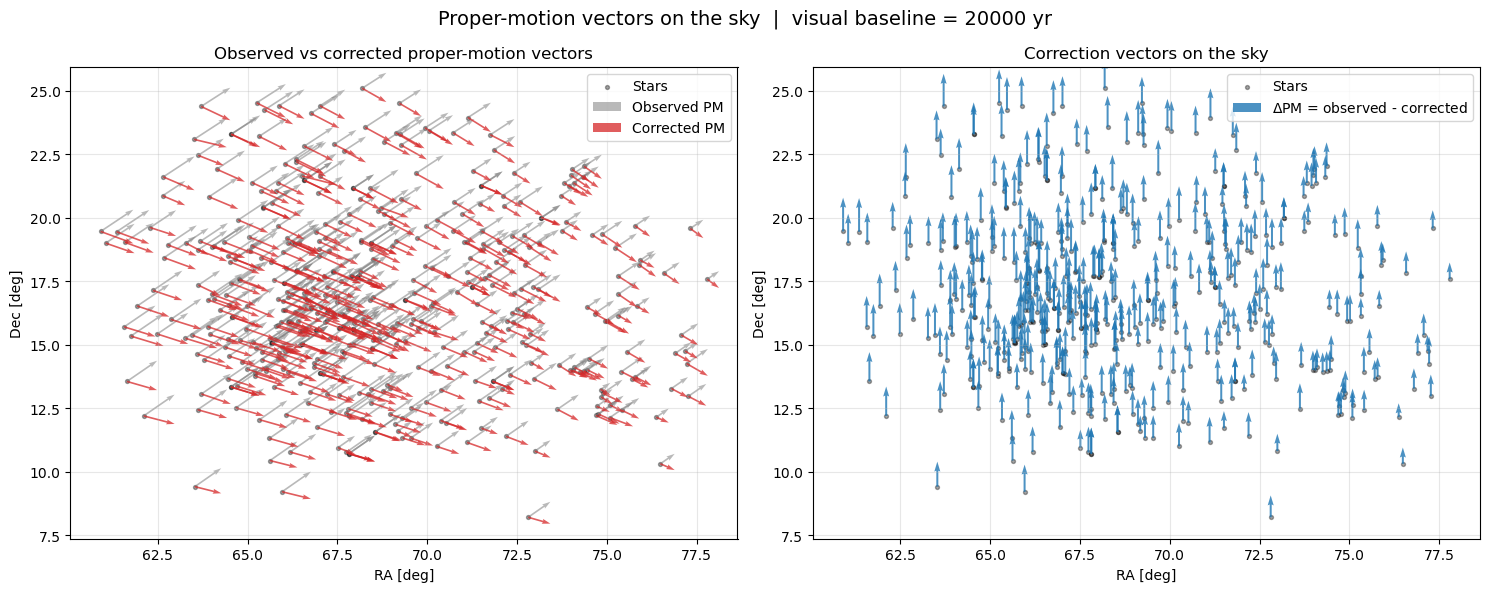

In [35]:
result_hyades_classic_solar["data"]["pmra_solar"] =  result_hyades_classic_solar["data"]["pmra"] - result_hyades_classic_solar["data"]["d_pmra_corr"]
result_hyades_classic_solar["data"]["pmdec_solar"] =  result_hyades_classic_solar["data"]["pmdec"] - result_hyades_classic_solar["data"]["d_pmdec_corr"]
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra_solar",
    pmdec_col="pmra_solar",
    pmra_corr_col="pmra_solar",
    pmdec_corr_col="pmdec_solar",
    years=20000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)

In [ ]:
# 3. Esfera interactiva
fig3 = plot_cluster_motion_geometry(
    result_hyades_sintetico_error_alld["data"],
    analysis_result=result_hyades_sintetico_error_alld,
    projection="sphere",
    title="Cúmulo 8 en esfera interactiva",
    save_html="cluster_hyades_sphere.html",
)

fig3.show()